# 09 — Anomali Sinyali Keşfi (Ground Truth Kullanmadan)

Kural tabanlı ve istatistiksel sinyaller — ML öncesi feature adayları.

> ML aşamasında `data/ground_truth/labels_30min.csv` ile karşılaştırarak
> precision/recall ölçebilirsin. **Bu notebook'ta açma.**

In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent
elif ROOT.name != 'eda' and (ROOT / 'eda').exists():
    ROOT = ROOT / 'eda'
sys.path.insert(0, str(ROOT))

from utils.data_loader import load_all, merge_ue1t_inventory
from utils.plots import setup_style

setup_style()
dfs = load_all()
ue1t = dfs['ue1t_30min'].copy()
inv = dfs['inventory_30min']

In [2]:
# Feature adayları — 30dk bazında
ue1t['satisiz'] = (ue1t['pompa_satis'] == 0).astype(int)
ue1t['kk_oran'] = np.where(ue1t['pompa_satis'] > 1,
                           ue1t['kayip_kazanc'] / ue1t['pompa_satis'], np.nan)
ue1t['saat'] = ue1t['saat_1'].dt.hour
ue1t['gece'] = ue1t['saat'].between(0, 5).astype(int)

print('Feature özet:')
print(ue1t[['kayip_kazanc','kk_oran','satisiz','gece']].describe())

Feature özet:
        kayip_kazanc       kk_oran        satisiz           gece
count  138194.000000  92759.000000  138194.000000  138194.000000
mean        0.289401     -0.011747       0.328777       0.250040
std        93.555517      2.613461       0.469770       0.433037
min    -14138.410000   -589.591743       0.000000       0.000000
25%        -0.930000     -0.009823       0.000000       0.000000
50%        -0.090000      0.001412       0.000000       0.000000
75%         0.700000      0.011684       1.000000       1.000000
max     13540.130000    116.745387       1.000000       1.000000


In [3]:
# Sinyal 1: Satışsız kayıp (statik sızıntı adayı)
satisiz_kayip = ue1t[(ue1t['pompa_satis']==0) & (ue1t['kayip_kazanc'] < -5)]
print('Satışsız kayıp >5 lt dönem:', len(satisiz_kayip))
top = satisiz_kayip.nsmallest(10, 'kayip_kazanc')
display(top[['saat_1','istasyon_kodu','tank_no','kayip_kazanc','donem_basi_stok','donem_sonu_stok']])

Satışsız kayıp >5 lt dönem: 450


,saat_1,istasyon_kodu,tank_no,kayip_kazanc,donem_basi_stok,donem_sonu_stok
110877,2026-01-16 00:00:00,IST_007,4,-4533.49,7746.15,7745.49
16091,2026-03-09 01:00:00,IST_001,2,-2295.75,2295.75,0.00
25923,2026-01-19 00:00:00,IST_002,4,-1515.91,1822.45,4973.58
136689,2026-03-21 13:00:00,IST_008,2,-451.40,1626.20,1174.80
81521,2026-01-27 02:30:00,IST_005,3,-349.92,11405.23,11055.31
12767,2026-02-23 04:30:00,IST_001,3,-284.93,5084.55,4799.62
65796,2026-02-10 03:30:00,IST_004,2,-236.09,4461.62,4225.53
71748,2026-03-06 22:30:00,IST_004,4,-227.90,2861.90,2634.00
74103,2026-03-16 18:00:00,IST_004,4,-183.49,2642.17,2458.68
7352,2026-01-31 15:00:00,IST_001,3,-182.00,3270.64,3088.64


In [4]:
# Sinyal 2: Gece satışsız düşüş (pompacı manipülasyonu adayı)
gece = ue1t[(ue1t['gece']==1) & (ue1t['pompa_satis']==0) & (ue1t['kayip_kazanc'] < -20)]
print('Gece satışsız düşüş >20 lt:', len(gece))
if len(gece):
    display(gece.nsmallest(5,'kayip_kazanc')[['saat_1','istasyon_kodu','tank_no','kayip_kazanc']])

Gece satışsız düşüş >20 lt: 20


,saat_1,istasyon_kodu,tank_no,kayip_kazanc
110877,2026-01-16 00:00:00,IST_007,4,-4533.49
16091,2026-03-09 01:00:00,IST_001,2,-2295.75
25923,2026-01-19 00:00:00,IST_002,4,-1515.91
81521,2026-01-27 02:30:00,IST_005,3,-349.92
12767,2026-02-23 04:30:00,IST_001,3,-284.93


In [5]:
# Sinyal 3: Yüksek kk_oran (dinamik sızıntı / decimal adayı)
high = ue1t[(ue1t['pompa_satis'] > 50) & (ue1t['kk_oran'].abs() > 0.05)]
print('|kk_oran| > 5% ve satış >50 lt:', len(high))
display(high.nlargest(10, 'kk_oran', keep='all')[['saat_1','istasyon_kodu','tank_no','pompa_satis','kayip_kazanc','kk_oran']].head(10))

|kk_oran| > 5% ve satış >50 lt: 1470


,saat_1,istasyon_kodu,tank_no,pompa_satis,kayip_kazanc,kk_oran
36182,2026-03-02 18:00:00,IST_002,3,115.98,13540.13,116.745387
36181,2026-03-02 18:00:00,IST_002,2,66.76,4972.38,74.481426
36184,2026-03-02 18:00:00,IST_002,5,180.93,9328.22,51.557066
52816,2026-03-08 18:30:00,IST_003,2,128.57,5497.95,42.762308
36180,2026-03-02 18:00:00,IST_002,1,312.72,11296.35,36.122889
80118,2026-01-17 09:00:00,IST_005,1,239.68,7816.81,32.613526
36183,2026-03-02 18:00:00,IST_002,4,106.61,1197.90,11.236282
81519,2026-01-27 02:30:00,IST_005,1,64.67,348.55,5.389671
86309,2026-03-01 09:30:00,IST_005,3,69.09,327.52,4.740483
118817,2026-02-26 13:30:00,IST_007,4,50.94,219.61,4.311150


In [6]:
# Sinyal 4: Seviye donması (şamandıra adayı) — stok değişmeden satış
ue1t_sorted = ue1t.sort_values(['istasyon_kodu','tank_no','saat_1'])
ue1t_sorted['stok_diff'] = ue1t_sorted.groupby(['istasyon_kodu','tank_no'])['donem_sonu_stok'].diff()
stuck = ue1t_sorted[(ue1t_sorted['pompa_satis'] > 30) & (ue1t_sorted['stok_diff'].abs() < 0.01)]
print('Satış var ama stok değişmedi:', len(stuck))
if len(stuck):
    display(stuck.head(8)[['saat_1','istasyon_kodu','tank_no','pompa_satis','donem_sonu_stok','kayip_kazanc']])

Satış var ama stok değişmedi: 45


,saat_1,istasyon_kodu,tank_no,pompa_satis,donem_sonu_stok,kayip_kazanc
36140,2026-03-02 14:00:00,IST_002,1,35.58,0.0,35.58
36145,2026-03-02 14:30:00,IST_002,1,174.02,0.0,174.02
36150,2026-03-02 15:00:00,IST_002,1,143.78,0.0,143.78
36155,2026-03-02 15:30:00,IST_002,1,83.05,0.0,83.05
36160,2026-03-02 16:00:00,IST_002,1,39.95,0.0,39.95
36165,2026-03-02 16:30:00,IST_002,1,116.48,0.0,116.48
36170,2026-03-02 17:00:00,IST_002,1,368.52,0.0,368.52
36175,2026-03-02 17:30:00,IST_002,1,63.37,0.0,63.37


In [7]:
# Sinyal 5: Su sıçraması
inv2 = inv.sort_values(['istasyon_kodu','tank_no','envanter_tarihi']).copy()
inv2['su_diff'] = inv2.groupby(['istasyon_kodu','tank_no'])['su_seviyesi_cm'].diff()
su = inv2[inv2['su_diff'] > 0.05]
print('Su sıçrama:', len(su))

Su sıçrama: 85


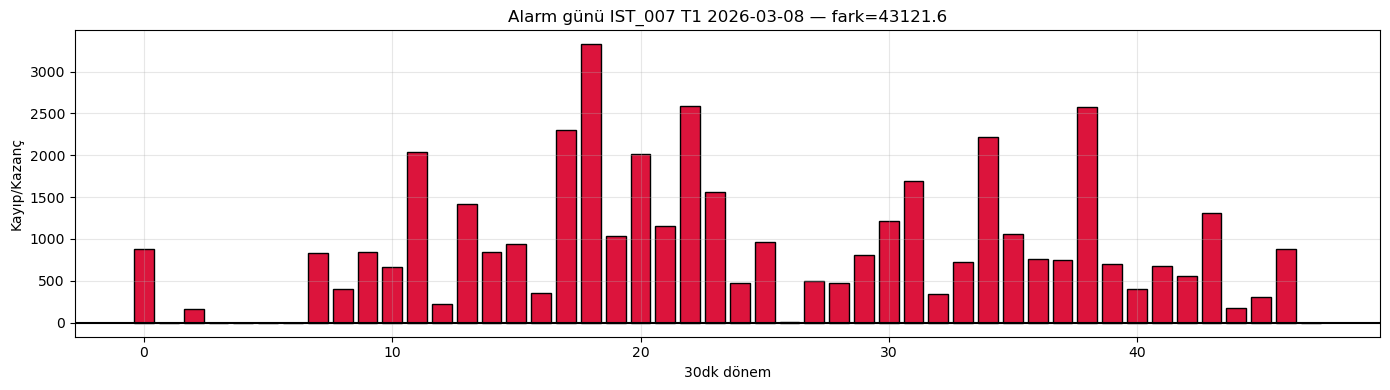

In [8]:
# Günlük alarm günlerinde 30dk profili
daily = dfs['daily']
alarm_gun = daily[daily['alarm']==1].nlargest(1, 'fark')
if len(alarm_gun):
    row = alarm_gun.iloc[0]
    u = ue1t[(ue1t.istasyon_kodu==row.istasyon_kodu)&(ue1t.tank_no==row.tank_no)
             &(ue1t.saat_1.dt.normalize()==row.tarih)]
    fig, ax = plt.subplots(figsize=(14, 4))
    ax.bar(range(len(u)), u['kayip_kazanc'], color='crimson', edgecolor='k')
    ax.axhline(0, color='k')
    ax.set_xlabel('30dk dönem')
    ax.set_ylabel('Kayıp/Kazanç')
    ax.set_title(f"Alarm günü {row.istasyon_kodu} T{row.tank_no} {row.tarih.date()} — fark={row.fark:.1f}")
    plt.tight_layout()
    plt.show()

## Sonuç ve sonraki adımlar

**Keşfedilen sinyaller → feature engineering:**
- `satisiz_kayip`, `kk_oran`, `gece_satisiz_dusus`
- `tx_ue1t_fark`, `su_diff`, `gecikme_dk`
- Manifold çift korelasyonu

**ML aşaması:**
1. Feature'ları birleştir
2. Zaman bazlı train/test split (son 20 gün test)
3. `ground_truth/labels_30min.csv` ile karşılaştır
4. Baseline: SEL alarm vs CatBoost/IsolationForest